In [1]:

# AGGLOMERATIVE HIERARCHICAL CLUSTERING
# Dataset: make_blobs (Synthetic Built-in Dataset)


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering

# Metrics used to evaluate clustering quality.
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)

# ParameterGrid allows us to manually test multiple combinations
# of hyperparameters.
from sklearn.model_selection import ParameterGrid

In [2]:
X, y = make_blobs(
    n_samples=500,       
    n_features=2,        
    centers=4, 
    cluster_std=1.2,    
    random_state=42     
)
df = pd.DataFrame(
    X,
    columns=["Feature_1", "Feature_2"]
)

# y contains the original generated cluster labels.
# IMPORTANT:
# We will NOT give y to AgglomerativeClustering.
# Clustering is unsupervised.
df["Actual_Label"] = y

df.head()

,Feature_1,Feature_2,Actual_Label
0,-7.459200,6.479711,3
1,-10.115891,-6.945263,2
2,7.267642,1.003212,1
3,-2.979727,7.258068,0
4,-5.438170,-7.369800,2


In [3]:
# Number of rows and columns
print("Shape:", df.shape)

# Check data types and memory information
print("\nDataset Information:")
df.info()

# Statistical summary
print("\nStatistical Summary:")
print(df.describe())

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

Shape: (500, 3)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Feature_1     500 non-null    float64
 1   Feature_2     500 non-null    float64
 2   Actual_Label  500 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 11.8 KB

Statistical Summary:
        Feature_1   Feature_2  Actual_Label
count  500.000000  500.000000    500.000000
mean    -3.389504    2.898642      1.500000
std      5.317120    6.377068      1.119154
min    -10.739011   -9.533472      0.000000
25%     -7.864154   -1.522165      0.750000
50%     -4.641039    4.449451      1.500000
75%      0.388884    8.237051      2.250000
max      8.334536   13.637564      3.000000

Missing Values:
Feature_1       0
Feature_2       0
Actual_Label    0
dtype: int64


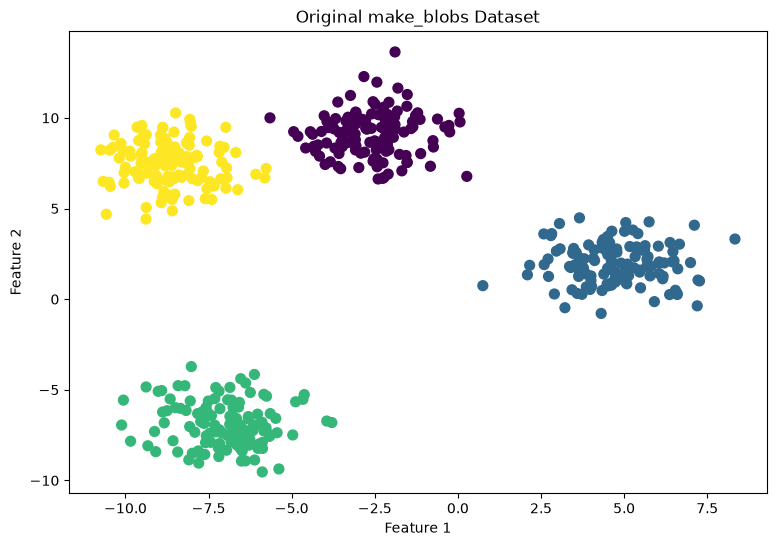

In [4]:

plt.figure(figsize=(9, 6))

plt.scatter(
    df["Feature_1"],
    df["Feature_2"],
    c=y,                 # Color using original generated labels
    cmap="viridis",
    s=50
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Original make_blobs Dataset")

plt.show()

In [5]:

scaler = StandardScaler()

# fit_transform:
# 1. fit -> learns mean and standard deviation
# 2. transform -> converts values into standardized values
X_scaled = scaler.fit_transform(X)

print("Before Scaling:")
print(X[:5])

print("\nAfter Scaling:")
print(X_scaled[:5])

Before Scaling:
[[ -7.45919977   6.47971121]
 [-10.11589116  -6.94526343]
 [  7.26764236   1.00321174]
 [ -2.97972741   7.25806819]
 [ -5.43817048  -7.36980004]]

After Scaling:
[[-0.76616127  0.56211657]
 [-1.26631026 -1.54518727]
 [ 2.00631549 -0.29752367]
 [ 0.07714464  0.68429443]
 [-0.3856821  -1.61182632]]


In [6]:
model = AgglomerativeClustering(
    n_clusters=4,
    linkage="ward"
)

# fit_predict:
# - fit -> learns the hierarchical clustering structure
# - predict -> returns cluster labels
clusters = model.fit_predict(X_scaled)

print("Cluster Labels:")
print(clusters[:20])

Cluster Labels:
[3 1 0 2 1 1 3 1 0 1 0 2 0 2 1 0 2 3 3 2]


In [7]:

df["Predicted_Cluster"] = clusters

df.head(10)

,Feature_1,Feature_2,Actual_Label,Predicted_Cluster
0,-7.459200,6.479711,3,3
1,-10.115891,-6.945263,2,1
2,7.267642,1.003212,1,0
3,-2.979727,7.258068,0,2
4,-5.438170,-7.369800,2,1
5,-5.883224,-7.907410,2,1
6,-5.766226,7.208251,3,3
7,-6.555079,-6.940395,2,1
8,3.358734,1.802314,1,0
9,-7.629409,-6.848800,2,1


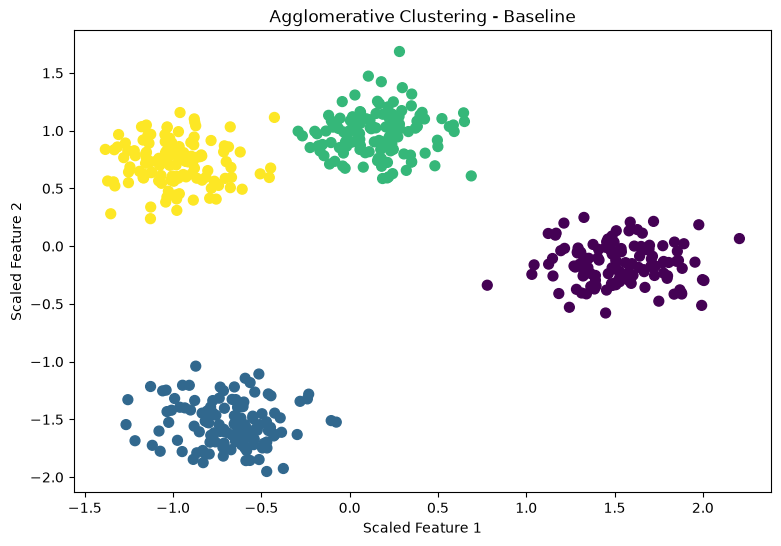

In [8]:

plt.figure(figsize=(9, 6))

plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=clusters,
    cmap="viridis",
    s=50
)

plt.xlabel("Scaled Feature 1")
plt.ylabel("Scaled Feature 2")
plt.title("Agglomerative Clustering - Baseline")

plt.show()

In [9]:
# ============================================================
# CLUSTERING PERFORMANCE
# ============================================================

# ------------------------------------------------------------
# 1. SILHOUETTE SCORE
# ------------------------------------------------------------
# Range:
# -1 to +1
#
# Higher is better.
#
# +1 -> points are very well separated
#  0 -> clusters overlap
# <0 -> points may be assigned to wrong clusters

silhouette = silhouette_score(
    X_scaled,
    clusters
)


# ------------------------------------------------------------
# 2. CALINSKI-HARABASZ SCORE
# ------------------------------------------------------------
# Higher is generally better.
#
# It compares:
# Between-cluster dispersion
#          VS
# Within-cluster dispersion

calinski = calinski_harabasz_score(
    X_scaled,
    clusters
)


# ------------------------------------------------------------
# 3. DAVIES-BOULDIN SCORE
# ------------------------------------------------------------
# Lower is better.
#
# A lower value means:
# - clusters are compact
# - clusters are well separated

davies = davies_bouldin_score(
    X_scaled,
    clusters
)


print("Baseline Performance")
print("---------------------")
print("Silhouette Score       :", silhouette)
print("Calinski-Harabasz      :", calinski)
print("Davies-Bouldin Score   :", davies)

Baseline Performance
---------------------
Silhouette Score       : 0.7549335038674485
Calinski-Harabasz      : 3870.1914878820758
Davies-Bouldin Score   : 0.3405159136581797


In [10]:
# ============================================================
# FINDING THE BEST NUMBER OF CLUSTERS
# ============================================================

cluster_results = []

# Try different values of K.
# We start from 2 because one cluster cannot really be evaluated
# as a clustering solution.

for k in range(2, 9):

    # Create a new Agglomerative model for each K.
    model = AgglomerativeClustering(
        n_clusters=k,
        linkage="ward"
    )

    # Generate cluster labels
    labels = model.fit_predict(X_scaled)

    # Evaluate the clustering
    silhouette = silhouette_score(
        X_scaled,
        labels
    )

    calinski = calinski_harabasz_score(
        X_scaled,
        labels
    )

    davies = davies_bouldin_score(
        X_scaled,
        labels
    )

    # Store results
    cluster_results.append({
        "n_clusters": k,
        "silhouette": silhouette,
        "calinski_harabasz": calinski,
        "davies_bouldin": davies
    })


# Convert list of dictionaries into DataFrame
cluster_results = pd.DataFrame(cluster_results)

cluster_results

,n_clusters,silhouette,calinski_harabasz,davies_bouldin
0,2,0.549265,447.178401,0.595121
1,3,0.726238,1732.433518,0.385845
2,4,0.754934,3870.191488,0.340516
3,5,0.637392,3231.044441,0.668460
4,6,0.504052,2875.595298,0.929035
5,7,0.395989,2662.583735,1.073273
6,8,0.301745,2522.340271,1.215402


In [11]:
# ============================================================
# BEST K
# ============================================================

# idxmax() returns the index of the row
# having the maximum silhouette score.

best_k = cluster_results.loc[
    cluster_results["silhouette"].idxmax(),
    "n_clusters"
]

print("Best Number of Clusters:", best_k)

Best Number of Clusters: 4


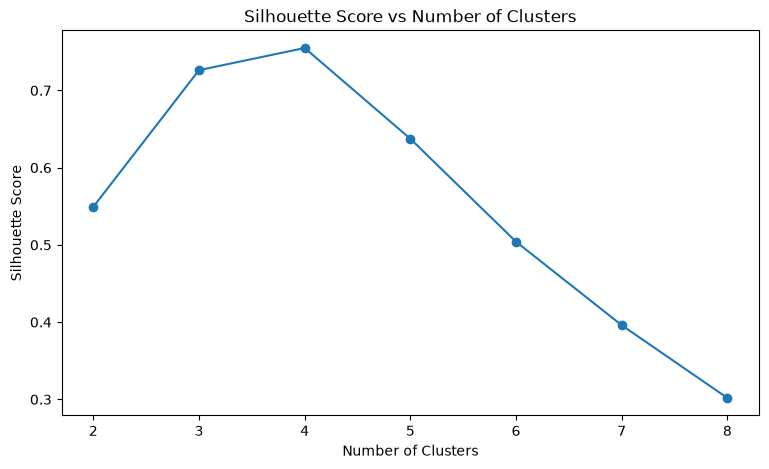

In [12]:
# ============================================================
# SILHOUETTE ANALYSIS
# ============================================================

plt.figure(figsize=(9, 5))

plt.plot(
    cluster_results["n_clusters"],
    cluster_results["silhouette"],
    marker="o"
)

plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs Number of Clusters")

plt.xticks(range(2, 9))

plt.show()

In [13]:
# ============================================================
# HYPERPARAMETER TUNING
# ============================================================

# Parameters we want to test.
#
# n_clusters:
# Number of clusters.
#
# linkage:
# How distance between clusters is calculated.
#
# metric:
# Distance measurement.

param_grid = {
    "n_clusters": range(2, 8),

    "linkage": [
        "ward",
        "complete",
        "average",
        "single"
    ],

    "metric": [
        "euclidean",
        "manhattan",
        "cosine"
    ]
}

In [15]:
# ============================================================
# GRID SEARCH FOR CLUSTERING
# ============================================================

tuning_results = []

# ParameterGrid creates every possible combination
# from param_grid.

for params in ParameterGrid(param_grid):

    linkage = params["linkage"]
    metric = params["metric"]

    # --------------------------------------------------------
    # IMPORTANT:
    # Ward linkage ONLY supports Euclidean distance.
    #
    # Therefore:
    # ward + manhattan -> invalid
    # ward + cosine    -> invalid
    #
    # We skip those combinations.
    # --------------------------------------------------------

    if linkage == "ward" and metric != "euclidean":
        continue

    # Create model with current parameters
    model = AgglomerativeClustering(
        n_clusters=params["n_clusters"],
        linkage=linkage,
        metric=metric
    )

    # Generate clusters
    labels = model.fit_predict(X_scaled)

    # Calculate evaluation metrics
    silhouette = silhouette_score(
        X_scaled,
        labels
    )

    calinski = calinski_harabasz_score(
        X_scaled,
        labels
    )

    davies = davies_bouldin_score(
        X_scaled,
        labels
    )

    # Save current experiment
    tuning_results.append({
        "n_clusters": params["n_clusters"],
        "linkage": linkage,
        "metric": metric,
        "silhouette": silhouette,
        "calinski_harabasz": calinski,
        "davies_bouldin": davies
    })


# Convert results into DataFrame
tuning_results = pd.DataFrame(tuning_results)

tuning_results.head()

,n_clusters,linkage,metric,silhouette,calinski_harabasz,davies_bouldin
0,2,ward,euclidean,0.549265,447.178401,0.595121
1,3,ward,euclidean,0.726238,1732.433518,0.385845
2,4,ward,euclidean,0.754934,3870.191488,0.340516
3,5,ward,euclidean,0.637392,3231.044441,0.668460
4,6,ward,euclidean,0.504052,2875.595298,0.929035


In [16]:
# ============================================================
# MODEL COMPARISON
# ============================================================

# For Silhouette:
# Higher = Better

best_models = tuning_results.sort_values(
    by="silhouette",
    ascending=False
)

best_models.head(10)

,n_clusters,linkage,metric,silhouette,calinski_harabasz,davies_bouldin
20,4,complete,cosine,0.755747,3882.313638,0.339698
26,4,average,euclidean,0.755747,3882.313638,0.339698
14,4,complete,manhattan,0.755747,3882.313638,0.339698
32,4,average,manhattan,0.755747,3882.313638,0.339698
38,4,average,cosine,0.755747,3882.313638,0.339698
2,4,ward,euclidean,0.754934,3870.191488,0.340516
8,4,complete,euclidean,0.736568,3531.713442,0.355429
13,3,complete,manhattan,0.726238,1732.433518,0.385845
7,3,complete,euclidean,0.726238,1732.433518,0.385845
1,3,ward,euclidean,0.726238,1732.433518,0.385845


In [17]:
# ============================================================
# BEST HYPERPARAMETERS
# ============================================================

best_params = best_models.iloc[0]

print("Best Hyperparameters")
print("--------------------")

print("Number of Clusters :", best_params["n_clusters"])
print("Linkage            :", best_params["linkage"])
print("Metric             :", best_params["metric"])
print("Silhouette         :", best_params["silhouette"])
print("Calinski-Harabasz  :", best_params["calinski_harabasz"])
print("Davies-Bouldin     :", best_params["davies_bouldin"])

Best Hyperparameters
--------------------
Number of Clusters : 4
Linkage            : complete
Metric             : cosine
Silhouette         : 0.755747194151021
Calinski-Harabasz  : 3882.3136383856995
Davies-Bouldin     : 0.33969783913897045


In [19]:
best_model = AgglomerativeClustering(
    n_clusters=int(best_params["n_clusters"]),
    linkage=best_params["linkage"],
    metric=best_params["metric"]
)

# Generate final cluster assignments
best_clusters = best_model.fit_predict(X_scaled)

In [20]:
# ============================================================
# FINAL MODEL PERFORMANCE
# ============================================================

final_silhouette = silhouette_score(
    X_scaled,
    best_clusters
)

final_calinski = calinski_harabasz_score(
    X_scaled,
    best_clusters
)

final_davies = davies_bouldin_score(
    X_scaled,
    best_clusters
)

print("Final Tuned Model")
print("-----------------")
print("Silhouette Score      :", final_silhouette)
print("Calinski-Harabasz     :", final_calinski)
print("Davies-Bouldin        :", final_davies)

Final Tuned Model
-----------------
Silhouette Score      : 0.755747194151021
Calinski-Harabasz     : 3882.3136383856995
Davies-Bouldin        : 0.33969783913897045


In [21]:
# ============================================================
# IMPROVEMENT AFTER TUNING
# ============================================================

# For Silhouette and Calinski-Harabasz:
# Higher is better -> positive improvement is good.

silhouette_improvement = (
    (final_silhouette - silhouette)
    / abs(silhouette)
) * 100

calinski_improvement = (
    (final_calinski - calinski)
    / abs(calinski)
) * 100


# For Davies-Bouldin:
# Lower is better.
#
# Therefore improvement is calculated in the opposite direction.

davies_improvement = (
    (davies - final_davies)
    / abs(davies)
) * 100


print(
    f"Silhouette Improvement: "
    f"{silhouette_improvement:.2f}%"
)

print(
    f"Calinski-Harabasz Improvement: "
    f"{calinski_improvement:.2f}%"
)

print(
    f"Davies-Bouldin Improvement: "
    f"{davies_improvement:.2f}%"
)

Silhouette Improvement: 60.35%
Calinski-Harabasz Improvement: 92.45%
Davies-Bouldin Improvement: 27.79%


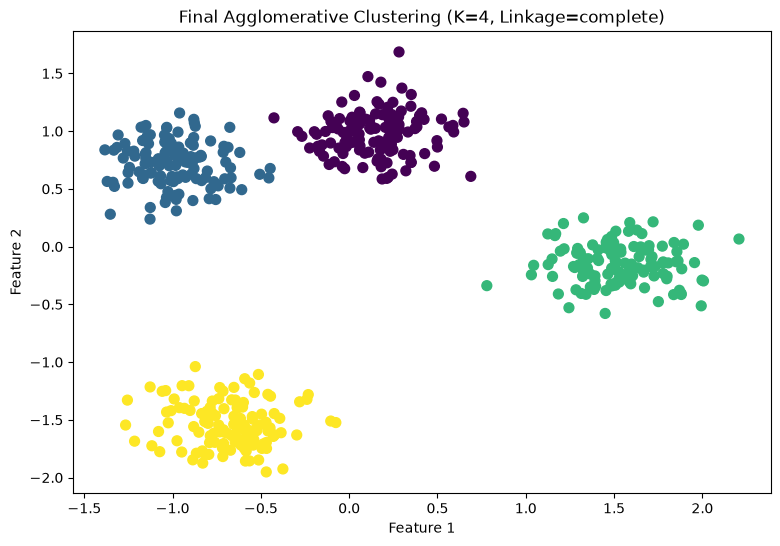

In [23]:
# ============================================================
# FINAL CLUSTER VISUALIZATION
# ============================================================

plt.figure(figsize=(9, 6))

plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=best_clusters,
    cmap="viridis",
    s=50
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.title(
    f"Final Agglomerative Clustering "
    f"(K={int(best_params['n_clusters'])}, "
    f"Linkage={best_params['linkage']})"
)

plt.show()

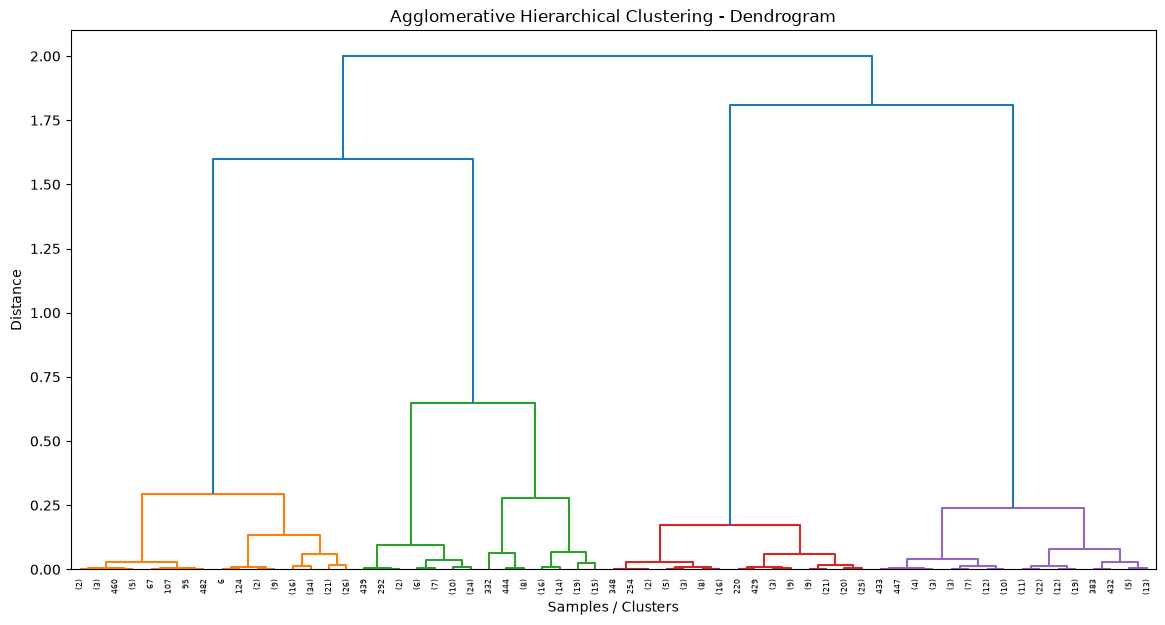

In [24]:
# ============================================================
# DENDROGRAM
# ============================================================

from scipy.cluster.hierarchy import dendrogram, linkage

# scipy's linkage function creates the hierarchical
# clustering tree required for the dendrogram.

Z = linkage(
    X_scaled,
    method=best_params["linkage"],
    metric=best_params["metric"]
)

plt.figure(figsize=(14, 7))

dendrogram(
    Z,
    truncate_mode="level",
    p=5
)

plt.title("Agglomerative Hierarchical Clustering - Dendrogram")
plt.xlabel("Samples / Clusters")
plt.ylabel("Distance")

plt.show()

In [25]:
# ============================================================
# FINAL CONCLUSION
# ============================================================

print("=" * 60)
print("AGGLOMERATIVE CLUSTERING - FINAL SUMMARY")
print("=" * 60)

print(f"Dataset              : make_blobs")
print(f"Samples              : {len(X)}")
print(f"Original Centers     : 4")

print("\nBest Hyperparameters:")
print(f"n_clusters           : {int(best_params['n_clusters'])}")
print(f"linkage              : {best_params['linkage']}")
print(f"metric               : {best_params['metric']}")

print("\nFinal Performance:")
print(f"Silhouette Score     : {final_silhouette:.4f}")
print(f"Calinski-Harabasz    : {final_calinski:.4f}")
print(f"Davies-Bouldin       : {final_davies:.4f}")

print("\nInterpretation:")
print("- Silhouette: Higher is better")
print("- Calinski-Harabasz: Higher is better")
print("- Davies-Bouldin: Lower is better")
print("=" * 60)

AGGLOMERATIVE CLUSTERING - FINAL SUMMARY
Dataset              : make_blobs
Samples              : 500
Original Centers     : 4

Best Hyperparameters:
n_clusters           : 4
linkage              : complete
metric               : cosine

Final Performance:
Silhouette Score     : 0.7557
Calinski-Harabasz    : 3882.3136
Davies-Bouldin       : 0.3397

Interpretation:
- Silhouette: Higher is better
- Calinski-Harabasz: Higher is better
- Davies-Bouldin: Lower is better
